# HyFlood: Historical Flood Reconstruction with Gaussian Processes

In the previous notebook, we simulated a set of representative compound
flooding scenarios with SFINCS and compressed the resulting flood maps with
**PCA**.

In this notebook, we build the **HyFlood surrogate model**: a statistical model
that relates the forcing conditions (waves, sea level and rain) to the flood
maps. Once trained, it can reconstruct a flood map for **any new scenario**
in a fraction of a second, without running SFINCS again.

**forcing conditions → GPR → PCs → inverse PCA → flood map**

We will use it to reconstruct the flooding of **every day of 2020** at
Newport (the same year we propagated with BinWaves), forced with observations:

| Driver | Source |
|:-------|:-------|
| Sea level | **GESLA** tide gauge at South Beach (NOAA 9435380) |
| Offshore waves | Directional spectra measured at **NDBC buoy 46050** |
| Rain | **ERA5** reanalysis |

With hundreds of daily flood maps we can compute **flood statistics** that a
handful of design storms cannot provide: how often each part of the city
floods and how deep it gets.

> **Inputs:**
> - From `01_Propagation.ipynb`: PCA model of the SFINCS flood maps
>   (`export/pca_model.pkl`), forcing of the simulated scenarios
>   (`export/mda_centroids.pkl`) and LHS parameter space (`export/lhs_dataset.pkl`).
> - From `toolkit/data/GESLA_data.ipynb`: sea-level record at South Beach
>   (`toolkit/data/outputs/GESLA_South_Beach_9435380_NOAA.nc`).
> - From `toolkit/data/NDBC_buoy_data.ipynb` (year 2020): directional
>   spectra at buoy 46050
>   (`toolkit/data/outputs/offshore_spectra_44.679_-124.535_20200101_20201231.nc`).
> - ERA5 hourly precipitation, downloaded in this notebook.

In [1]:
# Gaussian Processes with GPyTorch (not included in the course environment).
# CPU-only PyTorch, to avoid downloading the CUDA libraries.
%pip install -q "torch==2.14.1" "gpytorch==1.15.2" --index-url https://download.pytorch.org/whl/cpu --extra-index-url https://pypi.org/simple

Note: you may need to restart the kernel to use updated packages.


In [2]:
import logging
import os
import os.path as op

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray as xr

from bluemath_tk.core.io import load_model

from utils.gps import ExactGPInterpolation
from utils.historical import (
    build_daily_events,
    clip_to_training_range,
    historical_flood_statistics,
    load_gesla_sea_level,
    offshore_wave_parameters,
)
from utils.plotting import (
    plot_events_vs_training,
    plot_flood_statistics,
    plot_historical_forcing,
    plot_output_cases,
)
from utils.reconstruction import pcs_to_flood_maps

# Keep the notebook output clean
logging.getLogger("ExactGPInterpolation").setLevel(logging.WARNING)
logging.getLogger("PCA").setLevel(logging.WARNING)

In [3]:
root_dir = os.getcwd()

templates_dir = op.join(root_dir, "templates")
export_dir = op.join(root_dir, "export")
data_dir = op.join(root_dir, "..", "..", "..", "..", "toolkit", "data", "outputs")

dep_hr = xr.open_dataset(op.join(templates_dir, "Newport_UTM.tif"))

# Historical period to reconstruct
start_date, end_date = "2020-01-01", "2020-12-31"

## 1. Load the training data

The surrogate model learns the relationship between:

- **Inputs:** the forcing conditions of the scenarios simulated with SFINCS.
- **Targets:** the principal components (PCs) of their flood maps.

In [4]:
pca = load_model(op.join(export_dir, "pca_model.pkl"))

df_train_inputs = pd.read_pickle(op.join(export_dir, "mda_centroids.pkl"))
df_train_pcs = pca.pcs_df

print(f"{len(df_train_inputs)} training scenarios")
print(f"{df_train_inputs.shape[1]} input variables: {list(df_train_inputs.columns)}")
print(f"{df_train_pcs.shape[1]} principal components")

10 training scenarios
6 input variables: ['Hs', 'Tp', 'Dir', 'SL', 'precipitation', 'precip_duration']
8 principal components


In [5]:
df_train_inputs.round(2).head()

,Hs,Tp,Dir,SL,precipitation,precip_duration
0,11.48,23.13,345.65,3.70,85.36,22.04
1,0.74,6.50,184.02,1.02,41.21,1.92
2,0.61,21.17,188.95,3.57,3.65,21.18
3,9.50,22.02,352.51,1.04,3.21,8.90
4,11.44,20.82,162.51,3.17,48.47,1.15


## 2. Gaussian Process Regression (GPR)

In HySwash we used **RBF interpolation**. Here we use **Gaussian Process
Regression (GPR)**, which has two important advantages:

- It **learns** how smooth the response is along each input variable
  (the kernel hyperparameters) directly from the data, instead of fixing them
  beforehand.
- It provides not only a prediction, but also its **uncertainty**. This is
  especially valuable when, as here, the model is trained with few simulations.

A GP assumes that the target (each PC) is a smooth random function of the
inputs, whose correlation between two scenarios is given by a **kernel**. We use
the sum of an RBF and a Matérn kernel (`rbf+matern`), whose hyperparameters
are fitted by maximizing the marginal likelihood of the training data.

> ℹ️ `Dir` is a **directional variable** (359° is close to 1°). The model
> handles it by internally converting it into its u and v components.

We fit **one GP per principal component**.

In [6]:
gp = ExactGPInterpolation(kernel="rbf+matern")

gp.fit(
    subset_data=df_train_inputs,
    target_data=df_train_pcs,
    subset_directional_variables=["Dir"],
    verbose=0,
)

### 2.1. Check the fit

GPR is an interpolator: at the training scenarios it should reproduce the PCs
almost exactly, with a very small uncertainty. Let's check it for the first PCs,
expressing the errors as a percentage of the range of each PC.

In [7]:
pcs_train_pred = gp.predict(df_train_inputs, return_std=True, verbose=0)

pc_names = list(df_train_pcs.columns)
pc_range = df_train_pcs.max() - df_train_pcs.min()

df_fit = pd.DataFrame(
    {
        "Explained variance [%]": 100 * pca.explained_variance_ratio[: len(pc_names)],
        "Max. training error [%]": 100
        * (pcs_train_pred[pc_names] - df_train_pcs).abs().max() / pc_range,
        "Mean 95% CI width [%]": 100
        * pd.Series(
            {
                pc: (pcs_train_pred[f"{pc}_upper_ci"] - pcs_train_pred[f"{pc}_lower_ci"]).mean()
                for pc in pc_names
            }
        ) / pc_range,
    },
    index=pd.Index(pc_names, name="PC"),
)

df_fit.head(6).round(3)

,Explained variance [%],Max. training error [%],Mean 95% CI width [%]
PC,,,
PC1,65.885002,0.000,0.400
PC2,20.667999,0.000,0.400
PC3,9.318000,0.000,0.400
PC4,1.947000,11.425,41.041
PC5,1.571000,0.000,0.400
PC6,0.359000,0.000,0.400


### 2.2. Leave-one-out validation

Reproducing the training data is not enough: what matters is how well the model
predicts **scenarios it has never seen**.

In a **leave-one-out** validation, we remove one scenario from the training
set, fit the GP with the remaining ones, and compare its prediction with the
SFINCS flood map of the removed scenario.

> ⏱️ Each fit takes around 10 seconds, so we only validate a few scenarios.

In [8]:
cases_to_validate = [0, 3, 6]

sfincs_maps = pcs_to_flood_maps(pca, df_train_pcs.loc[cases_to_validate])
gp_maps = []

for case in cases_to_validate:
    gp_loo = ExactGPInterpolation(kernel="rbf+matern")
    gp_loo.fit(
        subset_data=df_train_inputs.drop(index=case),
        target_data=df_train_pcs.drop(index=case),
        subset_directional_variables=["Dir"],
        verbose=0,
    )
    pcs_loo = gp_loo.predict(df_train_inputs.loc[[case]], verbose=0)
    gp_maps.append(pcs_to_flood_maps(pca, pcs_loo).squeeze())

gp_maps = xr.concat(gp_maps, dim="case_num")

Each row compares the SFINCS flood map of a scenario (left) with the GPR
prediction obtained **without that scenario** (right).

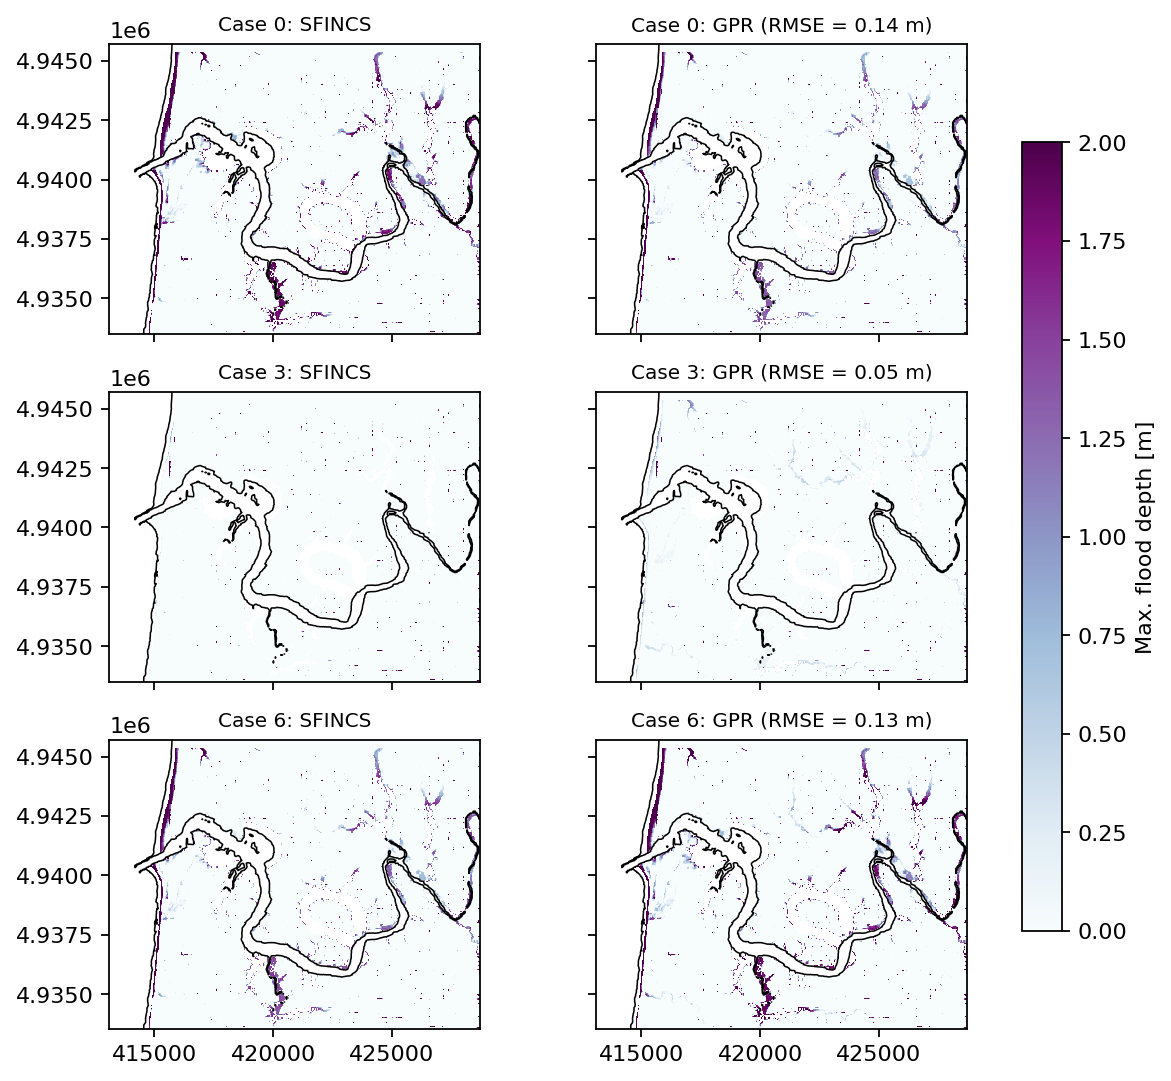

In [9]:
maps, titles = [], []

for i, case in enumerate(cases_to_validate):
    sfincs_map = sfincs_maps.isel(case_num=i)
    gp_map = gp_maps.isel(case_num=i)
    rmse = np.sqrt(((gp_map - sfincs_map) ** 2).mean()).item()

    maps += [sfincs_map, gp_map]
    titles += [f"Case {case}: SFINCS", f"Case {case}: GPR (RMSE = {rmse:.2f} m)"]

fig, axes = plot_output_cases(
    maps, dep_hr, ncols=2, cmap="BuPu", vmin=0, vmax=2, titles=titles, figsize=(9, 8)
)
plt.show()

> 💬 **Discussion:** Where are the largest errors? Why do you think the
> surrogate performs worse for some scenarios than for others? What would you
> do to improve it?

## 3. Historical forcing (2020)

The surrogate needs the same six variables it was trained with (`Hs`, `Tp`,
`Dir`, `SL`, `precipitation` and `precip_duration`). We now build them from
observations.

### 3.1. Sea level: GESLA

**GESLA** (Global Extreme Sea Level Analysis) gathers high-frequency tide-gauge
records from all over the world, with a common format and quality control. The
closest station to Newport is **South Beach** (NOAA 9435380), with hourly
data since 1967. We keep only the observations that GESLA marks for use
(`flag2 = 1`).

> ⚠️ **Vertical datum.** GESLA provides the sea levels in the original datum of
> each station, which for NOAA gauges is the station datum (STND). Our DEM,
> and therefore the `SL` of the SFINCS scenarios, is referenced to **NAVD88**,
> which at South Beach lies **1.626 m above STND**
> ([NOAA datums](https://tidesandcurrents.noaa.gov/datums.html?id=9435380)).
> Mixing datums would shift every flood map by more than 1.5 m!

In [10]:
gesla_path = op.join(data_dir, "GESLA_South_Beach_9435380_NOAA.nc")

stnd_to_navd88 = 1.626  # [m] height of NAVD88 above the station datum

sea_level = load_gesla_sea_level(gesla_path, datum_offset=stnd_to_navd88)
sea_level = sea_level.loc[start_date:end_date]

print(f"{len(sea_level):,} hourly sea levels from {sea_level.index[0]} to {sea_level.index[-1]}")
print(f"Range: {sea_level.min():.2f} to {sea_level.max():.2f} m NAVD88")

8,766 hourly sea levels from 2020-01-01 00:00:00 to 2020-12-31 23:00:00
Range: -0.91 to 3.09 m NAVD88


### 3.2. Offshore waves: NDBC buoy 46050

Buoy 46050 (Stonewall Bank, about 35 km off Newport) measures the
**directional wave spectrum**. These are the same offshore spectra we
propagated with BinWaves.

The surrogate was trained with parametric spectra defined by `Hs`, `Tp` and
`Dir`, so we summarize each measured spectrum with the same three parameters:

- `Hs` $= 4\sqrt{m_0}$, from the total energy of the spectrum.
- `Tp`: peak period.
- `Dir`: mean direction at the spectral peak.

> ℹ️ This is a simplification: when swell and wind sea coexist, the three
> parameters describe only the dominant system. A surrogate trained with the
> nearshore wave forcing (`Msetup`, `Hig`) would make use of the full spectrum.

> ⏱️ Computing the parameters of ~8,600 hourly spectra takes a while, so we
> save them the first time.

In [11]:
waves_path = op.join(export_dir, "offshore_waves_46050.pkl")

if op.exists(waves_path):
    waves = pd.read_pickle(waves_path)
else:
    spectra = xr.open_dataset(
        op.join(data_dir, "offshore_spectra_44.679_-124.535_20200101_20201231.nc")
    )
    waves = offshore_wave_parameters(spectra)
    waves.to_pickle(waves_path)

waves = waves.loc[start_date:end_date]
waves.describe().round(2)

,Hs,Tp,Dir
count,8621.00,8621.00,8621.00
mean,2.49,10.36,281.33
std,1.29,2.69,35.60
min,0.58,3.70,0.59
25%,1.56,8.33,265.52
50%,2.15,10.81,286.65
75%,3.14,12.12,302.87
max,9.81,19.05,359.86


### 3.3. Precipitation: ERA5

We use the hourly total precipitation of **ERA5** at the grid point closest
to Newport. The `toolkit/data/ERA5_DestinE_SingleLevels.ipynb` notebook
downloads it from DestinE, which requires an access token. Here we use the
[Open-Meteo archive API](https://open-meteo.com/en/docs/historical-weather-api),
which serves the same ERA5 data for a single point, for free and without an
account.

> ⚠️ ERA5 has a resolution of ~30 km, so it smooths short, intense bursts of
> rain and tends to **underestimate extreme rainfall**. A local rain gauge
> would be more accurate, but long hourly records are rarely available.

In [12]:
precip_path = op.join(export_dir, "era5_precipitation_newport.pkl")

if op.exists(precip_path):
    precipitation = pd.read_pickle(precip_path)["precipitation"]
else:
    response = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude": 44.62,
            "longitude": -124.05,
            "start_date": start_date,
            "end_date": end_date,
            "hourly": "precipitation",
            "models": "era5",
        },
        timeout=120,
    )
    response.raise_for_status()
    hourly = response.json()["hourly"]
    precipitation = pd.Series(
        hourly["precipitation"], index=pd.to_datetime(hourly["time"]), name="precipitation"
    )
    precipitation.to_frame().to_pickle(precip_path)

print(f"Total rainfall in 2020: {precipitation.sum():.0f} mm")

Total rainfall in 2020: 1572 mm


### 3.4. Daily compound events

SFINCS scenarios are **events**: a storm with a given sea level, waves and
rain, not a continuous time series. To use the surrogate, we split the
historical record into **one event per day**:

| Variable | Daily event |
|:---------|:------------|
| `SL` | Daily maximum sea level (high tide) |
| `Hs`, `Tp`, `Dir` | Offshore waves at the time of the high tide |
| `precipitation` | Total rainfall of the day |
| `precip_duration` | Number of hours of the day with rain (> 0.1 mm/h) |

Each daily flood map is therefore the **maximum flooding of that day**.

In [13]:
df_events = build_daily_events(sea_level, waves, precipitation)

print(f"{len(df_events):,} days with all drivers available")
df_events.describe().round(2)

361 days with all drivers available


,Hs,Tp,Dir,SL,precipitation,precip_duration
count,361.00,361.00,361.00,361.00,361.00,361.00
mean,2.48,10.33,281.46,2.32,4.34,5.95
std,1.24,2.61,33.41,0.26,8.18,7.30
min,0.66,4.55,166.41,1.70,0.00,1.00
25%,1.58,8.33,267.13,2.12,0.00,1.00
50%,2.15,10.81,286.19,2.28,0.10,1.00
75%,3.11,12.12,301.86,2.49,5.60,10.00
max,8.13,17.39,357.81,3.09,75.10,24.00


Let's look at the winter of 2020, with the largest storm of the year (11
January): the orange dots are the daily events that we will feed to the
surrogate.

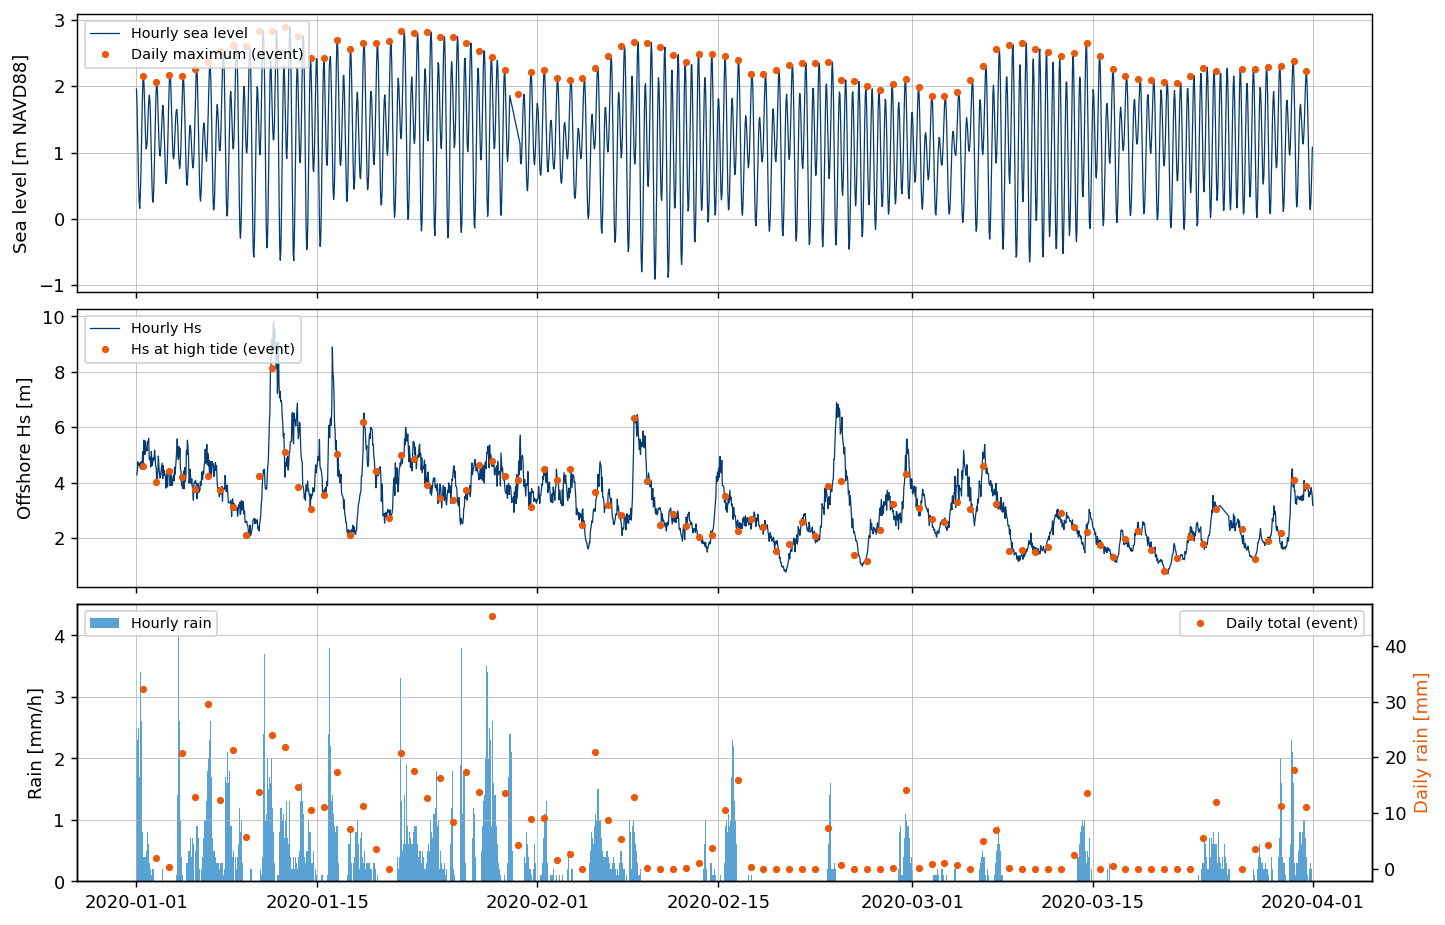

In [14]:
fig, axes = plot_historical_forcing(
    sea_level, waves, precipitation, df_events, start="2020-01-01", end="2020-03-31"
)
plt.show()

### 3.5. Stay within the training range!

The SFINCS scenarios were selected in `01_Propagation.ipynb` from an LHS
parameter space designed to cover the conditions observed at Newport. Let's
check how the historical events compare with the simulated scenarios, and
clip any event outside the LHS space (the GP should not extrapolate).

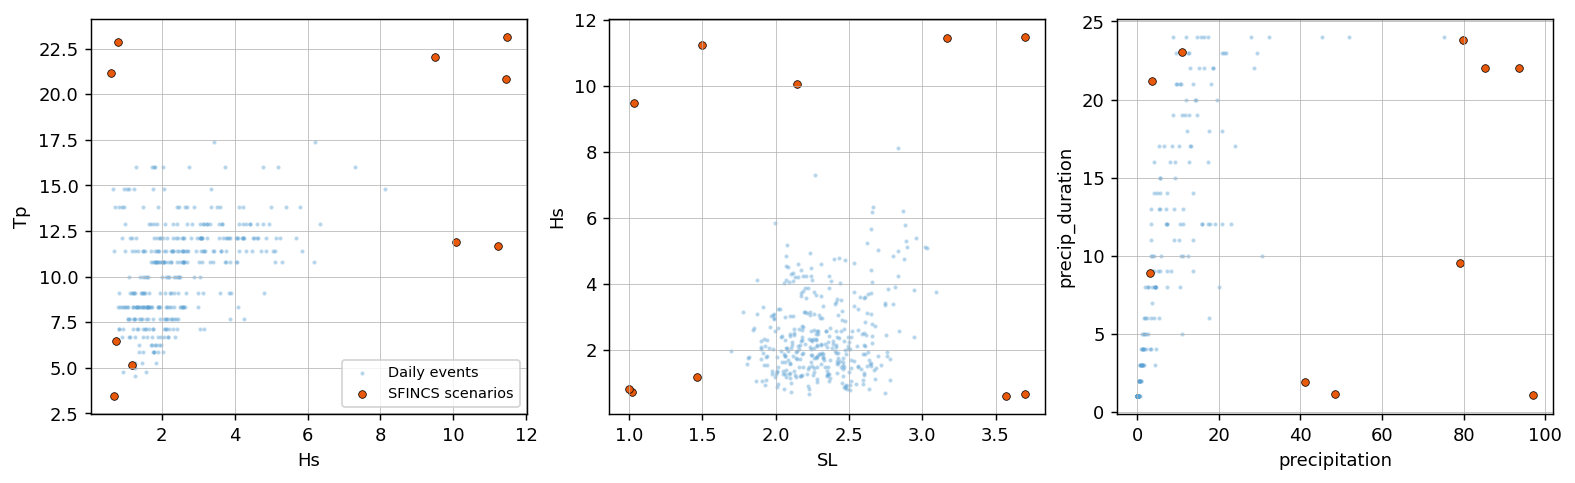

In [15]:
fig, axes = plot_events_vs_training(df_events, df_train_inputs)
plt.show()

In [16]:
df_lhs = pd.read_pickle(op.join(export_dir, "lhs_dataset.pkl"))

df_events_clipped, outside = clip_to_training_range(df_events, df_lhs[df_train_inputs.columns])

(100 * outside).round(2).rename("Events outside the training range [%]").to_frame()

,Events outside the training range [%]
Hs,0.0
Tp,0.0
Dir,0.0
SL,0.0
precipitation,0.0
precip_duration,0.0


## 4. Reconstruction of the daily flood maps

We now predict the PCs of every day with the GP, and reconstruct the flood
maps with the inverse PCA.

Storing hundreds of high-resolution maps would require several GB of memory,
so `historical_flood_statistics` reconstructs them in chunks and only keeps,
for every cell:

- the **number of flooded days** (flood depth > 0.1 m),
- the **maximum flood depth** of the year,

together with the daily **flooded area** of the whole domain.

In [17]:
%%time

# Predict in batches: the GP is much faster (and lighter) with small batches
batch_size = 500

pcs_hist = pd.concat(
    [
        gp.predict(df_events_clipped.iloc[i : i + batch_size].reset_index(drop=True), verbose=0)
        for i in range(0, len(df_events_clipped), batch_size)
    ]
)
pcs_hist.index = df_events_clipped.index

flood_stats = historical_flood_statistics(pca, pcs_hist, threshold=0.1)
flood_stats

CPU times: user 1.2 s, sys: 610 ms, total: 1.81 s
Wall time: 1.25 s


<xarray.Dataset> Size: 1MB
Dimensions:           (year: 1, y: 289, x: 369, time: 361)
Coordinates:
  * year              (year) int32 4B 2020
  * y                 (y) float64 2kB 4.946e+06 4.946e+06 ... 4.934e+06
  * x                 (x) float64 3kB 4.131e+05 4.132e+05 ... 4.287e+05
  * time              (time) datetime64[ns] 3kB 2020-01-01 ... 2020-12-31
Data variables:
    wet_days          (year, y, x) float64 853kB nan nan nan nan ... 0.0 0.0 0.0
    annual_max_depth  (year, y, x) float32 427kB nan nan nan nan ... 0.0 0.0 0.0
    n_days            (year) int64 8B 361
    flooded_area      (time) float64 3kB 6.57 5.688 6.475 ... 7.518 8.837 7.891

> ⏱️ Hundreds of flood maps in a few seconds. Running SFINCS for each day would
> have taken many hours, even with this small and coarse model.

## 5. Flood statistics

### 5.1. Flooded area time series

Which days flooded the most, and what caused them?

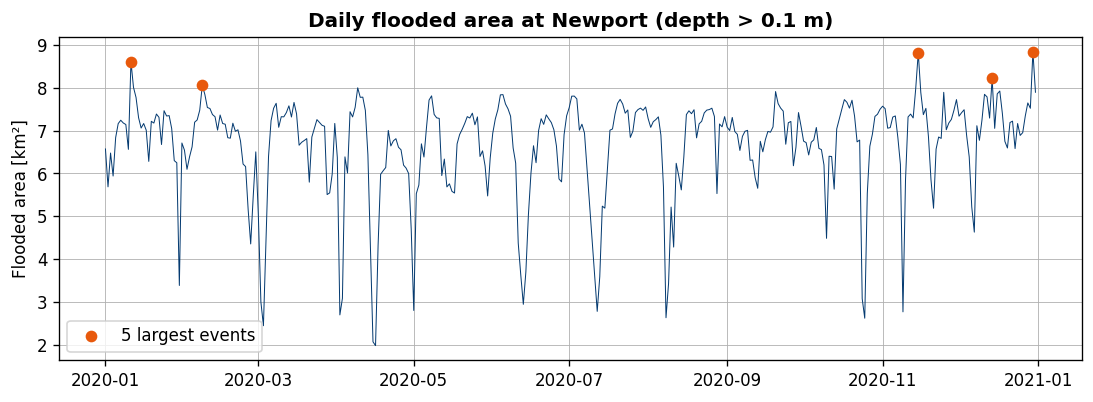

,Hs,Tp,Dir,SL,precipitation,precip_duration,Flooded area [km2]
time,,,,,,,
2020-12-30,6.21,17.39,303.10,2.87,17.9,12,8.84
2020-11-15,5.13,12.12,329.12,3.02,30.6,10,8.81
2020-01-11,8.13,14.81,279.10,2.84,24.0,17,8.61
2020-12-14,5.78,13.79,278.50,2.88,10.8,21,8.21
2020-02-08,6.34,12.90,284.34,2.67,12.9,17,8.05


In [18]:
flooded_area = flood_stats["flooded_area"].to_series()

fig, ax = plt.subplots(figsize=(11, 3.5), dpi=120)
ax.plot(flooded_area, color="#053B71", lw=0.6)

top_days = flooded_area.nlargest(5).index
ax.plot(top_days, flooded_area[top_days], "o", color="#E8590C", label="5 largest events")

ax.set_ylabel("Flooded area [km²]")
ax.set_title("Daily flooded area at Newport (depth > 0.1 m)", fontweight="bold")
ax.grid(lw=0.5)
ax.legend()
plt.show()

df_events.loc[top_days].assign(**{"Flooded area [km2]": flooded_area[top_days]}).round(2)

> ℹ️ Note that about **2 km² are flooded every day**: the beach and the margins
> of the bay and the river just above MHHW, which are reached by most high
> tides. Since each event keeps the daily high tide constant for a whole day,
> these areas appear "flooded" even on calm days.

### 5.2. Flood maps of the largest events

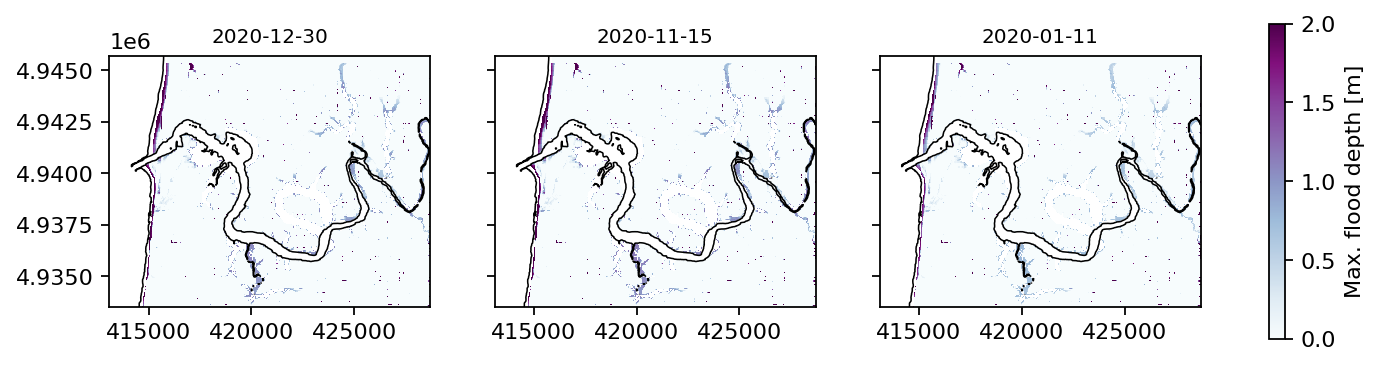

In [19]:
maps_top = pcs_to_flood_maps(pca, pcs_hist.loc[top_days[:3]])

fig, axes = plot_output_cases(
    list(maps_top),
    dep_hr,
    cmap="BuPu",
    vmin=0,
    vmax=2,
    titles=[f"{day:%Y-%m-%d}" for day in top_days[:3]],
    figsize=(11, 3.2),
)
plt.show()

> 💬 **Discussion:** Look at the drivers of the largest events in the table.
> Were they caused by a single extreme driver, or by the combination of
> moderate ones (**compound flooding**)?

### 5.3. How often does each cell flood?

From the daily maps we compute two statistics for every cell:

- **Wet days per year:** number of days with flood depth > 0.1 m. Dividing it
  by 365 gives the daily probability of flooding.
- **Maximum flood depth:** the deepest flooding of 2020.

> ℹ️ The buoy has some data gaps, so we normalize the count by the number of
> days reconstructed. The wet days are shown on a **logarithmic scale**: they
> range from cells reached by almost every high tide (beach and channel
> margins, > 300 days/year) to cells that only flooded once or twice.

> ⚠️ With a single year we cannot estimate **annual probabilities**, return
> periods, seasonality or interannual variability. Those statistics need a
> record of many years (e.g. running `toolkit/data/NDBC_buoy_data.ipynb` for
> 2008–2025).

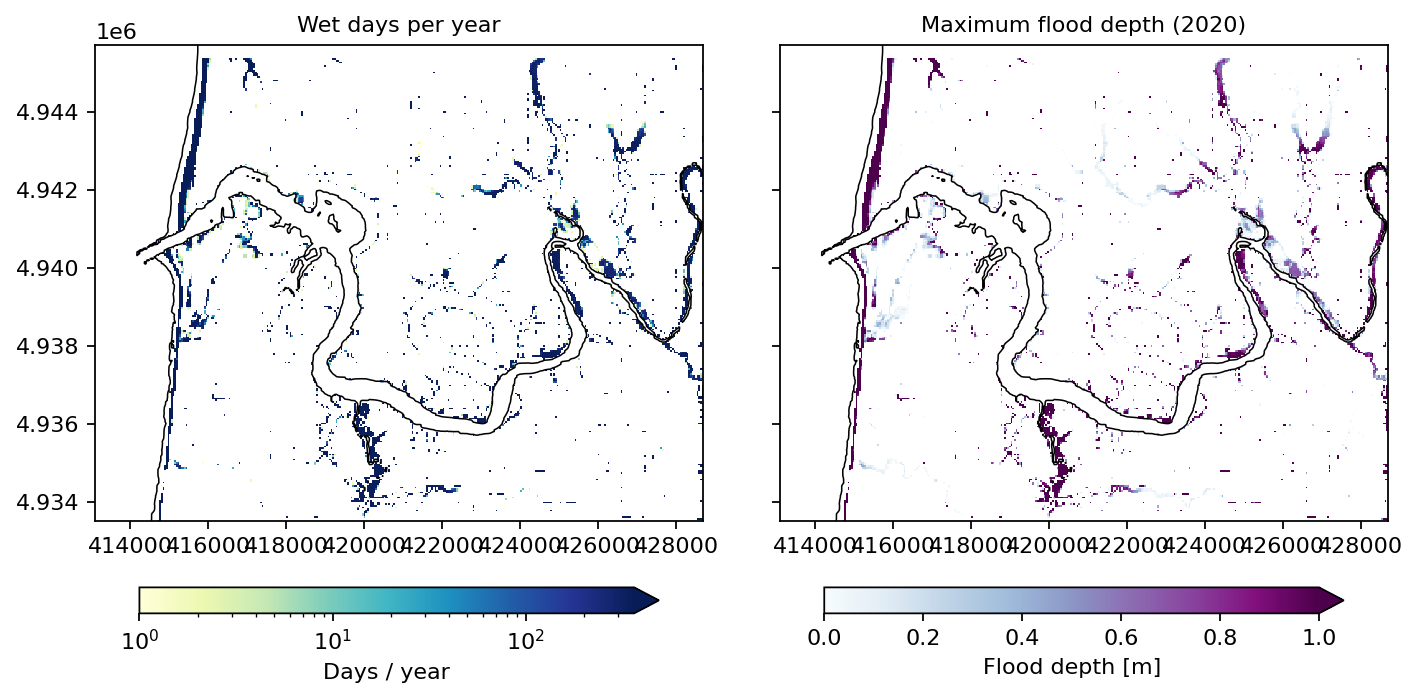

In [20]:
n_days = flood_stats["n_days"]

wet_days_per_year = (flood_stats["wet_days"] / n_days * 365.25).isel(year=0)
max_depth = flood_stats["annual_max_depth"].isel(year=0)

fig, axes = plot_flood_statistics(
    [wet_days_per_year, max_depth],
    dep_hr,
    titles=["Wet days per year", "Maximum flood depth (2020)"],
    labels=["Days / year", "Flood depth [m]"],
    cmaps=["YlGnBu", "BuPu"],
    vmax=[365, 1],
    log=[True, False],
    figsize=(9, 4.2),
)
plt.show()

### 5.4. Limitations

Before using these statistics, keep in mind the main assumptions behind them:

- **Constant forcing during the event.** Each SFINCS scenario keeps the sea
  level constant for a whole day, while the real tide only stays near its peak
  for a couple of hours. The daily maps therefore **overestimate** the flooding,
  especially in areas filled slowly through narrow channels.
- **Waves.** The measured spectra are summarized with three parameters, and
  HySwash saturates for the most energetic storms (see `01_Propagation.ipynb`).
- **Rain.** ERA5 underestimates short, intense rainfall bursts.
- **Surrogate uncertainty.** We used the GP mean. The GP uncertainty could be
  propagated by sampling the PCs, as we would do for a hazard assessment.

## Summary

In this notebook, we:

- Trained a **Gaussian Process Regression** surrogate model that relates the
  forcing conditions (waves, sea level and rain) to the PCs of the SFINCS flood
  maps, and validated it with a **leave-one-out** test.
- Built the **historical forcing** at Newport from observations: sea level from
  **GESLA** (converted to NAVD88), offshore wave parameters from the spectra of
  **NDBC buoy 46050**, and **ERA5** rainfall.
- Reconstructed **one flood map per day of 2020** in a few seconds.
- Computed **flood statistics**: wet days per year and maximum flood depth.
  With a longer record, the same workflow gives annual probabilities,
  seasonality and interannual variability.

This completes the HyFlood workflow:

**BinWaves → HySwash → SFINCS → PCA → GPR**

The same framework can be forced with **future scenarios** (e.g. adding sea
level rise to the historical sea levels) to see how these statistics will
change, or with thousands of **synthetic events** to estimate flood hazard
for return periods longer than the observed record.